# CompleteP: Depth × Normalization on Tiny Shakespeare

**Extended sweep: depths 2, 4, 8, 16, 32, 64, and 128; four normalization variants at every depth (28 runs, one seed).** The original five depths have completed 1,000 updates. First train the eight new depth/variant combinations to 1,000 updates; then continue all 28 runs to the total milestones 2,000, 3,000, 4,000, and 5,000 updates, in that order.

The question is whether normalization before $W_O$ and $W_2$ changes early loss improvement under CompleteP, and how this effect varies with depth. Compare A versus B and C versus D within each depth. Both extra locations are enabled together; their individual effects are not separated.

| Label | Existing pre-norms and final norm | Extra norm before $W_O$ and $W_2$ |
|---|---|---|
| A: LayerNorm | LayerNorm | No |
| B: LayerNorm + extra | LayerNorm | LayerNorm |
| C: RMSNorm | RMSNorm | No |
| D: RMSNorm + extra | RMSNorm | RMSNorm |

Run IDs include depth, e.g. `L04-A` and `L32-D`, so checkpoints and loss histories cannot be mixed across depths. All models use width 256, four heads, and MLP expansion four.

This notebook applies the CompleteP parameterization rules implemented in the author's minimal nanoGPT repository, **not only a residual multiplier**. It is a new loss experiment with matched training settings from Notebook 07, not a reproduction of the paper's full training setup or its 10-step coordinate check. Applying the hidden-norm optimizer role to extra norms and RMSNorm is an experimental extension, not a claim that the paper proves this ablation's behavior.

**Saving:** keep the same 5,000-update learning-rate schedule and sampled-window plan. Save resumable checkpoints every 100 updates and at each target. Preserve complete loss histories and separate metrics/figure snapshots for every milestone. The original 20-run, 1,000-update outputs are archived under `milestones/before-depth-extension-1000`.

## Shared architecture and normalization locations

Token embeddings + learned absolute position embeddings → dropout → $L$ sequential pre-norm Transformer layers → final norm → tied vocabulary projection → next-character cross-entropy.

Each layer performs:

1. Pre-norm → QKV matrices → causal attention → head concatenation → **optional extra norm (width 256)** → $W_O$ → dropout → multiply by $2/L$ → add to the residual stream.
2. Pre-norm → $W_1$ → **GELU** → **optional extra norm (width 1,024)** → $W_2$ → dropout → multiply by $2/L$ → add to the residual stream.

| Setting | Value |
|---|---|
| Layer counts | 2, 4, 8, 16, 32, 64, 128 |
| Hidden width | 256 |
| Attention heads / head width | 4 / 64 |
| MLP expansion / hidden width | 4× / 1,024 |
| Context / vocabulary | 256 / 65 character tokens |
| Nonlinearity / positions | GELU / learned absolute embeddings |
| Dropout | 0.2 in training; off during evaluation |
| Biases | Disabled in linear maps and norms |
| Norm scale / epsilon | Learnable gamma initialized to 1 / $10^{-5}$ |
| Embedding/output weights | Tied |
| Device / precision | MPS / float32; no mixed precision or compilation |

LayerNorm and RMSNorm operate over the final feature dimension at each token. RMSNorm replaces all existing pre-norms and the final norm in C/D. The additional norm is before each output matrix; residual scaling happens after the output matrix and dropout.

| Depth | A/C total parameters | B/D total parameters | Extra norm parameters |
|---:|---:|---:|---:|
| 2 | 1,656,320 | 1,658,880 | 2,560 |
| 4 | 3,230,208 | 3,235,328 | 5,120 |
| 8 | 6,377,984 | 6,388,224 | 10,240 |
| 16 | 12,673,536 | 12,694,016 | 20,480 |
| 32 | 25,264,640 | 25,305,600 | 40,960 |
| 64 | 50,446,848 | 50,528,768 | 81,920 |
| 128 | 100,811,264 | 100,975,104 | 163,840 |

Counts include learned position embeddings and count the tied output weights once. At different depths, parameter count and compute change; equal update counts are not equal compute budgets.

## CompleteP initialization, forward scales, and AdamW rules

Use base width $N_b=256$, base depth $L_b=2$, and $\alpha=1$. Define $m_N=N/N_b$ and $m_L=L/L_b$. Here $m_N=1$ for every run.

Both residual additions take the form $x_{next}=x+m_L^{-1}F(x)$. Scale the attention/MLP branch output, not the identity branch.

| Depth $L$ | $m_L$ | Residual multiplier $2/L$ | Hidden-block Adam epsilon |
|---:|---:|---:|---:|
| 2 | 1 | 1 | $10^{-8}$ |
| 4 | 2 | 1/2 | $5\times10^{-9}$ |
| 8 | 4 | 1/4 | $2.5\times10^{-9}$ |
| 16 | 8 | 1/8 | $1.25\times10^{-9}$ |
| 32 | 16 | 1/16 | $6.25\times10^{-10}$ |
| 64 | 32 | 1/32 | $3.125\times10^{-10}$ |
| 128 | 64 | 1/64 | $1.5625\times10^{-10}$ |

| Item | CompleteP rule | Value in this sweep |
|---|---|---|
| Embedding initialization std | $\sigma_{base}$ | 0.02 |
| All hidden matrix initialization std (QKV, $W_O$, $W_1$, $W_2$) | $\sigma_{base}/\sqrt{m_N}$ | 0.02 |
| Attention score multiplier | $1/d_{head}$ | 1/64 |
| Both residual multipliers | $m_L^{-1}$ | See depth table |
| Input / training-logit multipliers | 1 / $1/m_N$ | Both 1 |
| Norm gamma initialization | 1 | Includes extra norms |
| Hidden-matrix LR multiplier | $m_N^{-1}m_L^{\alpha-1}$ | 1 |
| Hidden-norm/bias LR multiplier | $m_L^{\alpha-1}$ | 1 |
| Embedding/final-norm LR multiplier | 1 | 1 |
| Hidden-matrix weight decay | $\lambda_{base}m_N$ | 0.1 |
| Embedding weight decay | $\lambda_{base}$ | 0.1 |
| Norm/bias weight decay | 0 | 0 |
| Hidden matrix/norm/bias Adam epsilon | $\epsilon_{base}/(m_Nm_L)$ | See depth table |
| Embedding/final-norm Adam epsilon | $\epsilon_{base}/m_N$ | $10^{-8}$ |

Output projections are initialized with std 0.02 here, replacing Notebook 07's nanoGPT rule $0.02/\sqrt{2L}$. Attention scaling also changes from $1/\sqrt{64}$ to $1/64$. Thus a comparison with Notebook 07 measures the combined parameterization difference, not the isolated effect of residual scaling.

The chosen base Adam epsilon is $10^{-8}$ to match Notebook 07; the author's minimal trainer uses a different default ($10^{-12}$). We retain the CompleteP **scaling rules** but explicitly choose matched base hyperparameters. The extra norms and RMSNorm use the same hidden-norm group rules as existing pre-norms. Final norm remains in its separate group.

Sources: [author's implementation README](../../CompleteP/README.md), [minimal model](../../CompleteP/model.py), [paper v4, Table 1](https://arxiv.org/html/2505.01618v4#S3). The paper's formal architecture/training setup differs from this minimal GELU, learned-position, tied-embedding implementation.

## Learning-rate schedule and relation to the author's experiments

To keep a useful 4-layer comparison with Notebook 07, use AdamW betas (0.9, 0.99), base LR 0.001, global gradient clipping 1.0, 100-update warmup, and cosine decay toward 0.0001 at update 5,000. The original stages stopped at 200 and then 1,000 updates. The extended sweep uses milestones 1,000, 2,000, 3,000, 4,000, and 5,000. These are total update counts, not extra updates per stage. Continuation uses the same global schedule and does not restart warmup.

The original paper uses linear warmup followed by linear decay. The author's short Figure 7 launcher instead uses a fixed learning rate (`decay_lr=False`), 10 configured iterations, batch 2 with accumulation 4, context 1,024, dropout 0, bias enabled, and beta2 0.95. **This notebook intentionally keeps Notebook 07's data/optimization protocol instead of copying that coordinate-check schedule.**

References: [paper Section 3](https://arxiv.org/html/2505.01618v4#S3), [author's CompleteP depth launcher](../../CompleteP/completep_examples/coord_check_shakespeare_char/depth_alpha_1_aka_completep/run.sh).

## Data, evaluation, comparison, and reproducibility

| Setting | Value |
|---|---|
| Dataset | Existing Tiny Shakespeare character train/validation split |
| Batch / context / accumulation | 64 / 256 / 1 |
| Training tokens per update | 16,384 |
| Maximum budget per run | 5,000 updates = 81,920,000 sampled tokens, including repeats |
| Final total budget | 28 runs × 5,000 = 140,000 updates; includes previously completed updates; compute varies by depth |
| Initialization / training-window / evaluation-window seeds | 1337 / 81001 / 81002 |
| Evaluation steps | 0 and every 50 completed updates through the current milestone |
| Evaluation batches | 20 fixed batches on each of train and val |
| Checkpoints | Step 0, every 100 updates, and the requested final target |
| Continuation horizon | Shared 5,000-update data plan and learning-rate schedule |

Use independent random generators to generate the training/evaluation windows. Reuse the same windows across all 28 runs. Within a depth, verify that all four variants share the same initial random matrices. Do not require identical matrices across different depths, where shapes differ. Constant extra norm scales do not consume initialization draws.

Cross-entropy is reported in nats per token. Evaluation turns dropout off, including on the training split; training-batch losses retain dropout. Save both histories. Fixed evaluation windows may overlap and are reused at every measurement.

Primary plots: train/validation curves for each depth, final validation loss versus depth, and paired differences `baseline loss − extra-norm loss` versus depth (positive means extra normalization helps). Preserve negative results. Results use one seed; a lower observed loss is not a multi-seed significance result or a compute-optimality claim.

The optional final comparison loads **Notebook 07's 4-layer results** and compares A/B/C/D at matching recorded updates up to the current milestone (at most 5,000). Never compare losses at different update counts as a matched-budget experiment. Compatibility checks require the same shared model/data/optimizer base settings and sampled windows. Initial output-projection scales, attention scales, residual scales, and epsilon-group rules deliberately differ.

This design does not include ordinary nanoGPT at every depth, so it cannot establish how the advantage of CompleteP over that baseline changes with depth. It does measure how the normalization ablation behaves within CompleteP.

## Run, save, resume, and inspect

Use the MiniP `.venv` Python kernel and run cells in order. Helper-definition cells do not train. The execution cell runs one milestone, sequentially over depths 2, 4, 8, 16, 32, 64, 128 and A/B/C/D within each depth. Existing runs already at that milestone are skipped; new runs start from step zero.

`RESUME_RUN_DIR` points to the existing experiment. `max_updates` is the TOTAL target for every run in this execution. The local launcher `run_completep_depth_stages.py` executes this notebook successively at 1,000, 2,000, 3,000, 4,000, and 5,000 updates. It verifies all 28 checkpoints after each milestone, then archives metrics, PNG/PDF figures, and the executed notebook under `milestones/<target>-updates` before proceeding. Restarting the launcher continues the unfinished milestone. It never trains beyond 5,000 updates.

Depth extension is append-only: an older signature may describe an unchanged prefix of the current variant list. Every other signature field must still match exactly, and the checkpoint must explicitly contain the requested variant. Model architecture and variant fields are also checked separately. Existing checkpoint weights, optimizer moments, and histories are not rewritten merely to add depths.

Only change the total target or checkpoint interval during continuation; keep dimensions, parameterization, schedule, data, seeds, and other settings fixed. `RESUME_RUN_DIR=None` deliberately starts a new experiment and should not be used for this continuation.

Checkpoints contain weights, AdamW state, global update count, complete loss history, and Python/NumPy/CPU/MPS RNG states. Each run has its own `L<depth>-<variant>-last.pt`. Saving writes a temporary file and atomically replaces the previous checkpoint. Keep the latest weight checkpoint per run; historical milestone metrics/figures are retained separately to limit disk use.

For a controlled stop, create `STOP_REQUESTED` in the result directory, or run the launcher with `--stop`. The loop checks it between optimizer updates, saves the last completed update, and stops the entire queue. Restart with `--resume` to clear that request and continue. Force-killing the process can lose roughly one checkpoint interval of work; an interrupted checkpoint write leaves the previous complete file intact.

Metrics beyond the last complete checkpoint are replaced by its consistent history on resume. Active-time histories exclude pauses and model construction/loading. Only load this experiment's trusted local checkpoints. Notebook 07 checkpoints are incompatible. Both notebooks and results remain local under the repository's existing Git-ignore settings.


In [1]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Standard-library utilities for paths, metadata, checkpointing, and timing.
from pathlib import Path
from datetime import datetime, timezone
from types import SimpleNamespace
from dataclasses import asdict
import copy
import random
import gc
import hashlib
import json
import math
import pickle
import shutil
import sys
import time
import uuid

# Numerical libraries and notebook display tools.
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Locate MiniP without depending on the notebook server launch directory.
PROJECT_ROOT = None  # Optional: Path('/absolute/path/to/Code/MiniP')
if PROJECT_ROOT is None:
    candidates = []
    for parent in (Path.cwd(), *Path.cwd().parents):
        candidates.extend([parent, parent / 'Code' / 'MiniP'])
    PROJECT_ROOT = next((p for p in candidates
                         if (p / 'model.py').is_file()
                         and (p / 'config/train_shakespeare_char.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Set PROJECT_ROOT to the MiniP repository and rerun this cell.')
PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
sys.path.insert(0, str(PROJECT_ROOT))
# Import the actual repository implementation; do not duplicate the Transformer.
import model as model_module
import train as train_module
from model import GPT, GPTConfig
from train import get_lr
assert Path(model_module.__file__).resolve() == PROJECT_ROOT / 'model.py', 'Restart the kernel: another model module is already loaded.'
assert Path(train_module.__file__).resolve() == PROJECT_ROOT / 'train.py', 'Restart the kernel: another train module is already loaded.'
print('Repository:', PROJECT_ROOT)
print('PyTorch:', torch.__version__)
### End normalization-ablation code ###


Matplotlib is building the font cache; this may take a moment.


Repository: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP
PyTorch: 2.14.0


## Editable experiment configuration

In [2]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# 1. Sweep dimensions: append the two new depths; preserve existing variant order.
DEPTHS = [2, 4, 8, 16, 32, 64, 128]
STAGE_TARGETS = [1000, 2000, 3000, 4000, 5000]  # Total updates; used by the stage launcher.
SETTINGS = dict(
    # 2. Shared architecture.
    n_embd=256,              # Residual-stream width, shared with Notebook 07.
    n_head=4,                # Head width = 256 / 4 = 64.
    mlp_ratio=4,             # model.py fixes MLP expansion at 4x -> 1,024.
    block_size=256,          # Context length in characters.
    vocab_size=65,           # Verified against prepared dataset metadata.
    dropout=0.2,             # Training only; evaluation disables dropout.
    bias=False,             # Disable linear biases and LayerNorm offsets.

    # 3. CompleteP parameterization (not a residual-only ablation).
    base_width=256,          # Width multiplier m_N = n_embd / base_width = 1.
    base_depth=2,            # Depth multiplier m_L = current depth / 2.
    depth_alpha=1.0,         # CompleteP: residual multiplier = m_L^(-1).
    init_std=0.02,           # Hidden matrix std = init_std / sqrt(m_N).
    norm_eps=1e-5,           # LayerNorm/RMSNorm epsilon; gamma initializes to 1.

    # 4. Data budget: max_updates is a TOTAL target for EACH depth/variant.
    batch_size=64,
    gradient_accumulation_steps=1,
    max_updates=1000,        # Current milestone; the launcher advances all 28 runs together.

    # 5. AdamW base settings, matched to Notebook 07; role scalings are below.
    beta1=0.9,
    beta2=0.99,
    adam_eps=1e-8,          # Base epsilon; hidden groups additionally divide by m_N*m_L.
    weight_decay=0.1,      # Base decay; hidden matrices multiply by m_N; norms use zero.
    grad_clip=1.0,         # Global clipping before each AdamW update.

    # 6. Same schedule as Notebook 07; intermediate milestones do not compress it.
    learning_rate=1e-3,
    warmup_iters=100,
    lr_decay_iters=5000,   # Also defines the shared full data-window plan.
    min_lr=1e-4,

    # 7. Evaluation and resumable saving.
    eval_interval=50,
    eval_batches=20,       # Per split: the same fixed windows for every run.
    checkpoint_interval=100,

    # 8. Initialization/dropout and independent sampling seeds.
    seed=1337,
    training_window_seed=81001,
    evaluation_window_seed=81002,

    # 9. Execution on the local Apple GPU.
    device='mps',
    dtype='float32',
)

# 10. None starts a new sweep; use the printed directory to continue that sweep.
RESUME_RUN_DIR = Path('/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/completep-depth-normalization/20260914T200740Z-176b0e19')
# RESUME_RUN_DIR = Path('/absolute/path/to/results/completep-depth-normalization/<run-id>')

# Preserve the four scientific labels and give every depth/variant a unique ID.
NORM_VARIANTS = [
    dict(id='A', name='LayerNorm', norm_type='layernorm', extra_output_norm=False),
    dict(id='B', name='LayerNorm + extra', norm_type='layernorm', extra_output_norm=True),
    dict(id='C', name='RMSNorm', norm_type='rmsnorm', extra_output_norm=False),
    dict(id='D', name='RMSNorm + extra', norm_type='rmsnorm', extra_output_norm=True),
]
VARIANTS = [
    {**v, 'norm_id': v['id'], 'id': f"L{depth:02d}-{v['id']}", 'depth': depth}
    for depth in DEPTHS for v in NORM_VARIANTS
]

# Validate the editable values before allocating models or creating output directories.
cfg = SimpleNamespace(**SETTINGS)
assert cfg.device == 'mps' and torch.backends.mps.is_available(), 'MPS is required.'
assert cfg.dtype == 'float32' and cfg.gradient_accumulation_steps == 1
assert cfg.mlp_ratio == 4 and cfg.n_embd % cfg.n_head == 0
assert cfg.base_width > 0 and cfg.base_depth > 0 and cfg.depth_alpha == 1.0
assert DEPTHS and len(set(DEPTHS)) == len(DEPTHS) and all(d > 0 for d in DEPTHS)
assert 0 < cfg.warmup_iters < cfg.lr_decay_iters
assert 0 < cfg.max_updates <= cfg.lr_decay_iters
assert cfg.eval_interval > 0 and cfg.eval_batches > 0 and cfg.checkpoint_interval > 0
assert cfg.checkpoint_interval % cfg.eval_interval == 0
assert hasattr(torch.nn.functional, 'rms_norm')
assert hasattr(torch.mps, 'get_rng_state') and hasattr(torch.mps, 'set_rng_state')
print(json.dumps(SETTINGS, indent=2))
print('Depths:', DEPTHS, '| Runs:', len(VARIANTS))
print('Updates per run / total:', cfg.max_updates, '/', len(VARIANTS) * cfg.max_updates)
print('Sampled training tokens per run:', cfg.max_updates * cfg.batch_size * cfg.block_size)
### End normalization-ablation code ###


{
  "n_embd": 256,
  "n_head": 4,
  "mlp_ratio": 4,
  "block_size": 256,
  "vocab_size": 65,
  "dropout": 0.2,
  "bias": false,
  "base_width": 256,
  "base_depth": 2,
  "depth_alpha": 1.0,
  "init_std": 0.02,
  "norm_eps": 1e-05,
  "batch_size": 64,
  "gradient_accumulation_steps": 1,
  "max_updates": 1000,
  "beta1": 0.9,
  "beta2": 0.99,
  "adam_eps": 1e-08,
  "weight_decay": 0.1,
  "grad_clip": 1.0,
  "learning_rate": 0.001,
  "warmup_iters": 100,
  "lr_decay_iters": 5000,
  "min_lr": 0.0001,
  "eval_interval": 50,
  "eval_batches": 20,
  "checkpoint_interval": 100,
  "seed": 1337,
  "training_window_seed": 81001,
  "evaluation_window_seed": 81002,
  "device": "mps",
  "dtype": "float32"
}
Depths: [2, 4, 8, 16, 32, 64, 128] | Runs: 28
Updates per run / total: 1000 / 28000
Sampled training tokens per run: 16384000


## Prepare shared data windows (no training)

In [3]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Read the already-prepared character-level split; never repartition on resume.
data_dir = PROJECT_ROOT / 'data' / 'shakespeare_char'
for filename in ('train.bin', 'val.bin', 'meta.pkl'):
    if not (data_dir / filename).is_file():
        raise FileNotFoundError(f'Missing prepared dataset file: {data_dir / filename}')
with (data_dir / 'meta.pkl').open('rb') as handle:
    metadata = pickle.load(handle)  # Trusted local dataset metadata.
assert metadata['vocab_size'] == cfg.vocab_size
data = {split: np.memmap(data_dir / f'{split}.bin', dtype=np.uint16, mode='r')
        for split in ('train', 'val')}
for split, values in data.items():
    assert len(values) > cfg.block_size and int(values.max()) < cfg.vocab_size
    print(split, 'characters:', len(values))

# Generate the FULL 5,000-update plan now. Each milestone uses its prefix;
# continuation uses the next row after the saved update. Independent generators do not alter dropout RNG.
training_rng = torch.Generator().manual_seed(cfg.training_window_seed)
evaluation_rng = torch.Generator().manual_seed(cfg.evaluation_window_seed)
training_windows = torch.randint(len(data['train']) - cfg.block_size,
                                (cfg.lr_decay_iters, cfg.batch_size), generator=training_rng)
evaluation_windows = {
    split: torch.randint(len(values) - cfg.block_size,
                         (cfg.eval_batches, cfg.batch_size), generator=evaluation_rng)
    for split, values in data.items()
}

def make_batch(split, indices):
    """Construct next-character input/target pairs from specified window starts."""
    values = data[split]
    t = cfg.block_size
    x = torch.stack([torch.from_numpy(values[i:i+t].astype(np.int64)) for i in indices])
    y = torch.stack([torch.from_numpy(values[i+1:i+t+1].astype(np.int64)) for i in indices])
    return x.to(cfg.device), y.to(cfg.device)

def file_hash(path):
    """Hash files in chunks to identify changes without keeping a second full copy."""
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

# The signature excludes the requested stop and save frequency. Variant extensions
# are accepted only when the old list is an unchanged prefix of the new list.
# Training/evaluation windows, source, data, PyTorch version, and all other settings
# must match before any checkpoint is loaded or experiment metadata is modified.
RESUME_SIGNATURE = dict(
    protocol_version=3, parameterization='completep',
    settings={k: v for k, v in SETTINGS.items() if k not in ('max_updates', 'checkpoint_interval')},
    variants=VARIANTS,
    torch_version=str(torch.__version__), numpy_version=np.__version__,
    source_hashes={f: file_hash(PROJECT_ROOT / f) for f in ('model.py', 'train.py')},
    data_hashes={f: file_hash(data_dir / f) for f in ('train.bin', 'val.bin', 'meta.pkl')},
    window_hashes={
        'training_plan': hashlib.sha256(training_windows.numpy().tobytes()).hexdigest(),
        **{'eval_' + s: hashlib.sha256(w.numpy().tobytes()).hexdigest() for s, w in evaluation_windows.items()},
    },
)

def require_compatible_signature(previous, current, variant_id=None):
    """Permit adding variants at the end, never altering an existing training protocol."""
    old_protocol = {k: v for k, v in previous.items() if k != 'variants'}
    new_protocol = {k: v for k, v in current.items() if k != 'variants'}
    old_variants = previous.get('variants', [])
    new_variants = current.get('variants', [])
    if old_protocol != new_protocol:
        raise ValueError('Cannot resume: settings, code, data, or library version changed.')
    if (not old_variants or len(old_variants) > len(new_variants)
            or old_variants != new_variants[:len(old_variants)]
            or len({v['id'] for v in old_variants}) != len(old_variants)):
        raise ValueError('Only an unchanged, append-only variant extension is compatible.')
    if variant_id is not None and variant_id not in {v['id'] for v in old_variants}:
        raise ValueError('This checkpoint signature does not contain the requested variant.')

print('Shared window plan:', tuple(training_windows.shape))
print('Current milestone prefix:', cfg.max_updates, 'updates')
### End normalization-ablation code ###


train characters: 1003854
val characters: 111540
Shared window plan: (5000, 64)
Current milestone prefix: 1000 updates


## Resolve CompleteP scalings (no model training)

In [4]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def completep_parameters(depth):
    """Resolve Table-1-style forward, initialization, and optimizer role scalings."""
    m_n = cfg.n_embd / cfg.base_width
    m_l = depth / cfg.base_depth
    alpha = cfg.depth_alpha
    hidden_std = cfg.init_std / math.sqrt(m_n)
    residual = m_l ** (-alpha)
    depth_lr = m_l ** (alpha - 1)
    hidden_eps = cfg.adam_eps / m_n * m_l ** (-alpha)
    outer_eps = cfg.adam_eps / m_n

    # The existing model roster puts extra pre-output norms in hidden_norm too.
    # Final norm remains separate, as in the author's minimal implementation.
    groups = {
        'embedding': dict(lr_scale=1.0, eps=outer_eps, weight_decay=cfg.weight_decay),
        'hidden_norm': dict(lr_scale=depth_lr, eps=hidden_eps, weight_decay=0.0),
        'hidden_weight': dict(lr_scale=depth_lr / m_n, eps=hidden_eps,
                              weight_decay=cfg.weight_decay * m_n),
        'hidden_bias': dict(lr_scale=depth_lr, eps=hidden_eps, weight_decay=0.0),
        'final_norm': dict(lr_scale=1.0, eps=outer_eps, weight_decay=0.0),
    }
    return dict(width_multiplier=m_n, depth_multiplier=m_l, alpha=alpha,
                hidden_std=hidden_std, residual_multiplier=residual,
                attention_scale=1.0 / (cfg.n_embd // cfg.n_head),
                training_output_multiplier=1.0 / m_n, groups=groups)

# Inspect the resolved numerical values before running any model.
rows = ['| Depth | m_L | Residual multiplier | Hidden std | Hidden LR multiplier | Hidden Adam eps |',
        '|---:|---:|---:|---:|---:|---:|']
for depth in DEPTHS:
    p = completep_parameters(depth)
    rows.append(f"| {depth} | {p['depth_multiplier']:g} | {p['residual_multiplier']:g} | "
                f"{p['hidden_std']:g} | {p['groups']['hidden_weight']['lr_scale']:g} | "
                f"{p['groups']['hidden_weight']['eps']:.3g} |")
display(Markdown('\n'.join(rows)))
### End normalization-ablation code ###


| Depth | m_L | Residual multiplier | Hidden std | Hidden LR multiplier | Hidden Adam eps |
|---:|---:|---:|---:|---:|---:|
| 2 | 1 | 1 | 0.02 | 1 | 1e-08 |
| 4 | 2 | 0.5 | 0.02 | 1 | 5e-09 |
| 8 | 4 | 0.25 | 0.02 | 1 | 2.5e-09 |
| 16 | 8 | 0.125 | 0.02 | 1 | 1.25e-09 |
| 32 | 16 | 0.0625 | 0.02 | 1 | 6.25e-10 |
| 64 | 32 | 0.03125 | 0.02 | 1 | 3.13e-10 |
| 128 | 64 | 0.015625 | 0.02 | 1 | 1.56e-10 |

## Model construction, evaluation, and result helpers (no training)

In [5]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def make_model(variant):
    """Construct one CompleteP model and optimizer; fingerprint shared initial matrices."""
    random.seed(cfg.seed)
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    p = completep_parameters(variant['depth'])
    model_config = GPTConfig(
        n_layer=variant['depth'], n_embd=cfg.n_embd, n_head=cfg.n_head,
        block_size=cfg.block_size, vocab_size=cfg.vocab_size,
        dropout=cfg.dropout, bias=cfg.bias, init_std=cfg.init_std,
        norm_type=variant['norm_type'], extra_output_norm=variant['extra_output_norm'],
        norm_eps=cfg.norm_eps,

        # Override all hidden matrix initializations, including both output projections.
        qkv_init_std=p['hidden_std'], mlp_in_init_std=p['hidden_std'],
        attn_out_init_std=p['hidden_std'], mlp_out_init_std=p['hidden_std'],

        # Scale branch outputs immediately before residual addition in model.py.
        attention_scale=p['attention_scale'], input_multiplier=1.0,
        attn_residual_multiplier=p['residual_multiplier'],
        mlp_residual_multiplier=p['residual_multiplier'],
        training_output_multiplier=p['training_output_multiplier'],
    )
    model = GPT(model_config).float()
    digest = hashlib.sha256()
    for name, parameter in sorted(model.named_parameters()):
        if parameter.ndim == 2:
            digest.update(name.encode())
            digest.update(parameter.detach().cpu().numpy().tobytes())
    model = model.to(cfg.device)
    optimizer = model.configure_optimizers(
        cfg.weight_decay, cfg.learning_rate, (cfg.beta1, cfg.beta2), cfg.device,
        adam_eps=cfg.adam_eps, group_settings=p['groups'],
    )
    return model, optimizer, digest.hexdigest()

@torch.no_grad()
def evaluate(model):
    """Measure both splits on fixed windows with dropout disabled; restore train mode."""
    previous_mode = model.training
    model.eval()
    losses = {}
    try:
        for split in ('train', 'val'):
            values = []
            for indices in evaluation_windows[split]:
                x, y = make_batch(split, indices)
                _, loss = model(x, y)
                values.append(loss.item())
            losses[split + '_loss'] = sum(values) / len(values)
        assert all(math.isfinite(value) for value in losses.values()), 'Non-finite evaluation loss'
    finally:
        model.train(previous_mode)
    return losses

def save_metrics(experiment, run_dir):
    """Atomically replace readable metrics; checkpoints remain the resume authority."""
    temporary = run_dir / 'metrics.tmp.json'
    temporary.write_text(json.dumps(experiment, indent=2, allow_nan=False))
    temporary.replace(run_dir / 'metrics.json')
### End normalization-ablation code ###


## Checkpoint and random-state helpers (definitions only)

In [6]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def synchronize_device():
    """Make timing and RNG snapshots wait for queued GPU work to finish."""
    if cfg.device == 'mps':
        torch.mps.synchronize()

def capture_rng_state():
    """Save every random stream used by the experiment, including GPU dropout."""
    state = dict(python=random.getstate(), numpy=np.random.get_state(),
                 torch_cpu=torch.get_rng_state())
    if cfg.device == 'mps':
        state['torch_mps'] = torch.mps.get_rng_state()
    return state

def restore_rng_state(state):
    """Restore AFTER constructing/loading the model so construction cannot consume it."""
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch_cpu'])
    if cfg.device == 'mps':
        torch.mps.set_rng_state(state['torch_mps'])

def save_checkpoint(model, optimizer, result, run_dir):
    """Save weights, AdamW state, progress/history, and RNG as one coherent checkpoint."""
    synchronize_device()
    checkpoint = dict(
        resume_signature=RESUME_SIGNATURE,
        model_args=asdict(model.config), model=model.state_dict(),
        optimizer=optimizer.state_dict(), completed_updates=result['completed_updates'],
        result=copy.deepcopy(result), rng=capture_rng_state(),
    )
    # Replace only this variant's latest checkpoint; preserve the previous good file
    # if serialization is interrupted before replacement. Every depth/variant has its own file.
    destination = run_dir / f"{result['id']}-last.pt"
    temporary = destination.with_suffix('.tmp.pt')
    torch.save(checkpoint, temporary)
    temporary.replace(destination)

def load_checkpoint(model, optimizer, variant, run_dir):
    """Validate and restore a trusted local checkpoint, including Adam's accumulated moments."""
    path = run_dir / f"{variant['id']}-last.pt"
    # CPU loading preserves CPU RNG tensors. Model/optimizer loading moves parameter
    # states to the current parameter device. This file must be our own trusted checkpoint.
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    require_compatible_signature(checkpoint['resume_signature'], RESUME_SIGNATURE, variant['id'])
    if checkpoint['model_args'] != asdict(model.config):
        raise ValueError(f'Model architecture or normalization differs: {path}')
    result = checkpoint['result']
    if any(result[k] != variant[k] for k in variant):
        raise ValueError(f'Checkpoint belongs to a different variant: {path}')
    completed = checkpoint['completed_updates']
    if completed != result['completed_updates'] or len(result['training']) != completed:
        raise ValueError(f'Checkpoint history/update count mismatch: {path}')
    if completed > cfg.max_updates:
        raise ValueError('The requested target is earlier than an existing checkpoint.')
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    # Do this last: the next forward must see the saved dropout random stream.
    restore_rng_state(checkpoint['rng'])
    return result
### End normalization-ablation code ###


## Training and continuation loop (definition only)

In [7]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def run_variant(variant, experiment, run_dir):
    """Train/resume one variant to the TOTAL target and keep its existing history."""
    model, optimizer, fingerprint = make_model(variant)
    fingerprints = experiment.setdefault('initial_matrix_fingerprints', {})
    depth_key = str(variant['depth'])
    if depth_key not in fingerprints:
        fingerprints[depth_key] = fingerprint
    assert fingerprint == fingerprints[depth_key], 'Initial matrices differ within a depth.'

    checkpoint_path = run_dir / f"{variant['id']}-last.pt"
    if checkpoint_path.exists():
        result = load_checkpoint(model, optimizer, variant, run_dir)
        print(f"Resuming {variant['id']} from {result['completed_updates']} updates.")
    else:
        # A later variant may not have started before a previous session was interrupted.
        result = dict(**variant, model_config=asdict(model.config),
                      parameterization=completep_parameters(variant['depth']),
                      total_params=sum(p.numel() for p in model.parameters()),
                      initial_matrix_fingerprint=fingerprint, common_initial_matrices_verified=True,
                      completed_updates=0, training=[], evaluations=[],
                      training_seconds=0.0, evaluation_seconds=0.0, elapsed_seconds=0.0)

    # Replace metrics-only history with the coherent checkpoint history on resume.
    experiment['results'] = [r for r in experiment['results'] if r['id'] != variant['id']]
    experiment['results'].append(result)
    experiment['results'].sort(key=lambda r: r['id'])
    if result['completed_updates'] == cfg.max_updates:
        result['status'] = 'complete'
        save_metrics(experiment, run_dir)
        print(f"Skipping {variant['id']}: target already reached.")
        return

    result['status'] = 'running'
    # Accumulate active time across sessions, excluding the pause and model construction.
    elapsed_before_session = result['elapsed_seconds']
    synchronize_device()
    session_start = time.perf_counter()

    def record_evaluation():
        """Append a post-update evaluation without changing the dropout RNG stream."""
        synchronize_device()
        start = time.perf_counter()
        losses = evaluate(model)
        synchronize_device()
        result['evaluation_seconds'] += time.perf_counter() - start
        result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
        step = result['completed_updates']
        result['evaluations'].append(dict(
            completed_updates=step, tokens_seen=step * cfg.batch_size * cfg.block_size,
            elapsed_seconds=result['elapsed_seconds'],
            training_seconds=result['training_seconds'],
            evaluation_seconds=result['evaluation_seconds'], **losses,
        ))
        save_metrics(experiment, run_dir)
        print(f"{variant['id']} | {variant['name']:<18} | {step:4d} updates | "
              f"train {losses['train_loss']:.4f} | val {losses['val_loss']:.4f}")

    model.train()
    if not result['evaluations']:
        record_evaluation()  # Step 0: evaluate the fresh model once.
        save_checkpoint(model, optimizer, result, run_dir)

    # completed_updates is the number ALREADY done. Resume uses the next global
    # data-window index and learning rate, without repeating earlier updates.
    for update_index in range(result['completed_updates'], cfg.max_updates):
        # A controlled stop saves at a safe boundary, after the previous full update.
        if (run_dir / 'STOP_REQUESTED').exists():
            result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
            result['status'] = 'interrupted'
            save_checkpoint(model, optimizer, result, run_dir)
            save_metrics(experiment, run_dir)
            raise KeyboardInterrupt('Controlled stop requested; last completed update saved.')
        synchronize_device()
        update_start = time.perf_counter()
        learning_rate = get_lr(update_index, cfg)  # Global schedule: never restart warmup.
        for group in optimizer.param_groups:
            # Apply the parameterization's role-specific LR multiplier every update.
            group['lr'] = learning_rate * group.get('lr_scale', 1.0)

        # Use the next row of the fixed window plan; compute and validate gradients.
        optimizer.zero_grad(set_to_none=True)
        x, y = make_batch('train', training_windows[update_index])
        logits, loss = model(x, y)
        loss_value = loss.item()
        if not math.isfinite(loss_value):
            raise FloatingPointError(f'Non-finite loss in {variant["id"]} at index {update_index}')
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        gradient_norm_value = gradient_norm.item()
        if not math.isfinite(gradient_norm_value):
            raise FloatingPointError(f'Non-finite gradient in {variant["id"]} at index {update_index}')

        # Count progress only AFTER AdamW completes the update successfully.
        optimizer.step()
        synchronize_device()
        duration = time.perf_counter() - update_start
        result['training_seconds'] += duration
        step = update_index + 1
        result['completed_updates'] = step
        result['training'].append(dict(
            completed_updates=step, loss=loss_value, learning_rate=learning_rate,
            pre_clip_gradient_norm=gradient_norm_value, update_seconds=duration,
        ))

        # Evaluation is deterministic and does not advance training/dropout RNG.
        if step % cfg.eval_interval == 0 or step == cfg.max_updates:
            record_evaluation()

        # Save after both the update and any evaluation. The final target always saves,
        # even when it is not a multiple of checkpoint_interval.
        if step % cfg.checkpoint_interval == 0 or step == cfg.max_updates:
            result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
            result['status'] = 'complete' if step == cfg.max_updates else 'running'
            save_checkpoint(model, optimizer, result, run_dir)
            save_metrics(experiment, run_dir)
### End normalization-ablation code ###


## Execute the current milestone — training starts in the next cell

The existing five depths are already at 1,000 updates. At the first extended milestone they are skipped, while the eight new runs at depths 64/128 train from zero to 1,000. Subsequent executions continue all 28 runs to the requested total target. The stage launcher executes this cell and the plotting cells at every milestone. Helpers above do not launch training.


In [8]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Rerun preceding cells after editing settings so the window plan/signature are current.
assert vars(cfg) == SETTINGS, 'Rerun the configuration cell after changing SETTINGS.'
assert len(training_windows) == cfg.lr_decay_iters

if RESUME_RUN_DIR is None:
    # Fresh run: use a unique directory, leaving older experiments untouched.
    RUN_DIR = PROJECT_ROOT / 'results' / 'completep-depth-normalization' / (
        datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:8]
    )
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    experiment = dict(
        created_utc=datetime.now(timezone.utc).isoformat(), settings=SETTINGS.copy(),
        resume_signature=RESUME_SIGNATURE, variants=VARIANTS, results=[],
        python_version=sys.version, source_root=str(PROJECT_ROOT), sessions=[], status='running',
    )
    # Preserve source snapshots for inspecting the exact implementation later.
    for name in ('model.py', 'train.py'):
        shutil.copy2(PROJECT_ROOT / name, RUN_DIR / name)
    shutil.copy2(PROJECT_ROOT / 'config/train_shakespeare_char.py', RUN_DIR / 'shakespeare-preset.py')
    shutil.copy2(PROJECT_ROOT / 'notebooks/08-completep-depth-normalization-ablation.ipynb', RUN_DIR / 'notebook.ipynb')
else:
    # Resume only this named experiment; do not search for an arbitrary latest run.
    RUN_DIR = Path(RESUME_RUN_DIR).expanduser().resolve()
    experiment = json.loads((RUN_DIR / 'metrics.json').read_text())
    require_compatible_signature(experiment['resume_signature'], RESUME_SIGNATURE)
    if experiment['variants'] != experiment['resume_signature']['variants']:
        raise ValueError('Saved variant metadata does not match its signature.')
    if (RUN_DIR / 'STOP_REQUESTED').exists():
        raise KeyboardInterrupt('Stop request is still set; use the launcher --resume to continue.')
    # Check every expected checkpoint exists before changing saved experiment metadata.
    # Variants never started are allowed to have no checkpoint.
    for previous in experiment['results']:
        if not (RUN_DIR / f"{previous['id']}-last.pt").is_file():
            raise FileNotFoundError(f"Missing checkpoint for existing variant {previous['id']}.")
    if cfg.max_updates < experiment['settings']['max_updates']:
        raise ValueError('Use the same or a larger total target when resuming.')
    # Record an additive extension without modifying any older checkpoint file.
    if experiment['variants'] != VARIANTS:
        experiment.setdefault('depth_extensions', []).append(dict(
            utc=datetime.now(timezone.utc).isoformat(),
            previous_variants=experiment['variants'], extended_variants=VARIANTS,
        ))
    experiment['settings'] = SETTINGS.copy()
    experiment['variants'] = copy.deepcopy(VARIANTS)
    experiment['resume_signature'] = copy.deepcopy(RESUME_SIGNATURE)

# Record sessions separately: pausing between stages does not inflate training time.
experiment['sessions'].append(dict(started_utc=datetime.now(timezone.utc).isoformat(),
                                   target_updates=cfg.max_updates, resumed=RESUME_RUN_DIR is not None))
experiment['status'] = 'running'
save_metrics(experiment, RUN_DIR)
print('Run directory (copy this into RESUME_RUN_DIR for continuation):', RUN_DIR)
try:
    for variant in VARIANTS:
        if (RUN_DIR / 'STOP_REQUESTED').exists():
            raise KeyboardInterrupt('Controlled stop requested; queue will not start another variant.')
        run_variant(variant, experiment, RUN_DIR)
        # Each function releases its model/optimizer before the next variant starts.
        gc.collect()
        if cfg.device == 'mps':
            torch.mps.empty_cache()
except BaseException:
    # Do not checkpoint a partially executed optimizer update; keep the last good file.
    experiment['status'] = 'interrupted'
    save_metrics(experiment, RUN_DIR)
    raise
else:
    experiment['status'] = 'complete'
    experiment['sessions'][-1]['finished_utc'] = datetime.now(timezone.utc).isoformat()
    save_metrics(experiment, RUN_DIR)
    print('All', len(VARIANTS), 'depth/variant runs reached', cfg.max_updates, 'updates. Metrics:', RUN_DIR / 'metrics.json')
### End normalization-ablation code ###


Run directory (copy this into RESUME_RUN_DIR for continuation): /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/completep-depth-normalization/20260914T200740Z-176b0e19
number of parameters: 1.59M


num decayed parameter tensors: 10, with 1,655,040 parameters
num non-decayed parameter tensors: 5, with 1,280 parameters
using fused AdamW: False
Resuming L02-A from 1000 updates.
Skipping L02-A: target already reached.
number of parameters: 1.59M
num decayed parameter tensors: 10, with 1,655,040 parameters
num non-decayed parameter tensors: 9, with 3,840 parameters
using fused AdamW: False
Resuming L02-B from 1000 updates.
Skipping L02-B: target already reached.


number of parameters: 1.59M
num decayed parameter tensors: 10, with 1,655,040 parameters
num non-decayed parameter tensors: 5, with 1,280 parameters
using fused AdamW: False
Resuming L02-C from 1000 updates.
Skipping L02-C: target already reached.
number of parameters: 1.59M
num decayed parameter tensors: 10, with 1,655,040 parameters
num non-decayed parameter tensors: 9, with 3,840 parameters
using fused AdamW: False
Resuming L02-D from 1000 updates.
Skipping L02-D: target already reached.


number of parameters: 3.16M
num decayed parameter tensors: 18, with 3,227,904 parameters
num non-decayed parameter tensors: 9, with 2,304 parameters
using fused AdamW: False
Resuming L04-A from 1000 updates.
Skipping L04-A: target already reached.
number of parameters: 3.17M
num decayed parameter tensors: 18, with 3,227,904 parameters
num non-decayed parameter tensors: 17, with 7,424 parameters
using fused AdamW: False
Resuming L04-B from 1000 updates.


Skipping L04-B: target already reached.
number of parameters: 3.16M
num decayed parameter tensors: 18, with 3,227,904 parameters
num non-decayed parameter tensors: 9, with 2,304 parameters
using fused AdamW: False
Resuming L04-C from 1000 updates.
Skipping L04-C: target already reached.


...

L128-B | LayerNorm + extra  |  250 updates | train 2.2007 | val 2.2314


L128-B | LayerNorm + extra  |  300 updates | train 2.1019 | val 2.1477


L128-B | LayerNorm + extra  |  350 updates | train 2.0310 | val 2.0888


L128-B | LayerNorm + extra  |  400 updates | train 1.9701 | val 2.0513


KeyboardInterrupt: Controlled stop requested; last completed update saved.

## Display saved results — no training required

The cells below are independent of the training cells. Run this section directly after an interruption to display the saved results; it does not construct models, load optimizer checkpoints, or resume training.

Compare the four normalization variants at the **same saved target step**. Include a depth only when **all four variants have an evaluation at that step**. In the current paused experiment this displays **2, 4, 8, 16, 32, and 64 layers at 1,000 updates**; 128 layers are excluded because the four runs are incomplete. When all runs reach a later milestone, this section automatically displays the newly completed depths at that target.

The first chart shows saved training/validation curves. The next cell displays the depth trend and two summary tables: validation loss and the benefit of extra normalization. Positive benefit means lower validation loss with extra normalization. The interruption output above is retained as a record of the controlled pause.


Matplotlib is building the font cache; this may take a moment.


Saved experiment status: interrupted. Display only; no training is executed.
Comparison step: 1000 | Included depths: [2, 4, 8, 16, 32, 64]
Excluded depths (incomplete four-way comparison): [128]


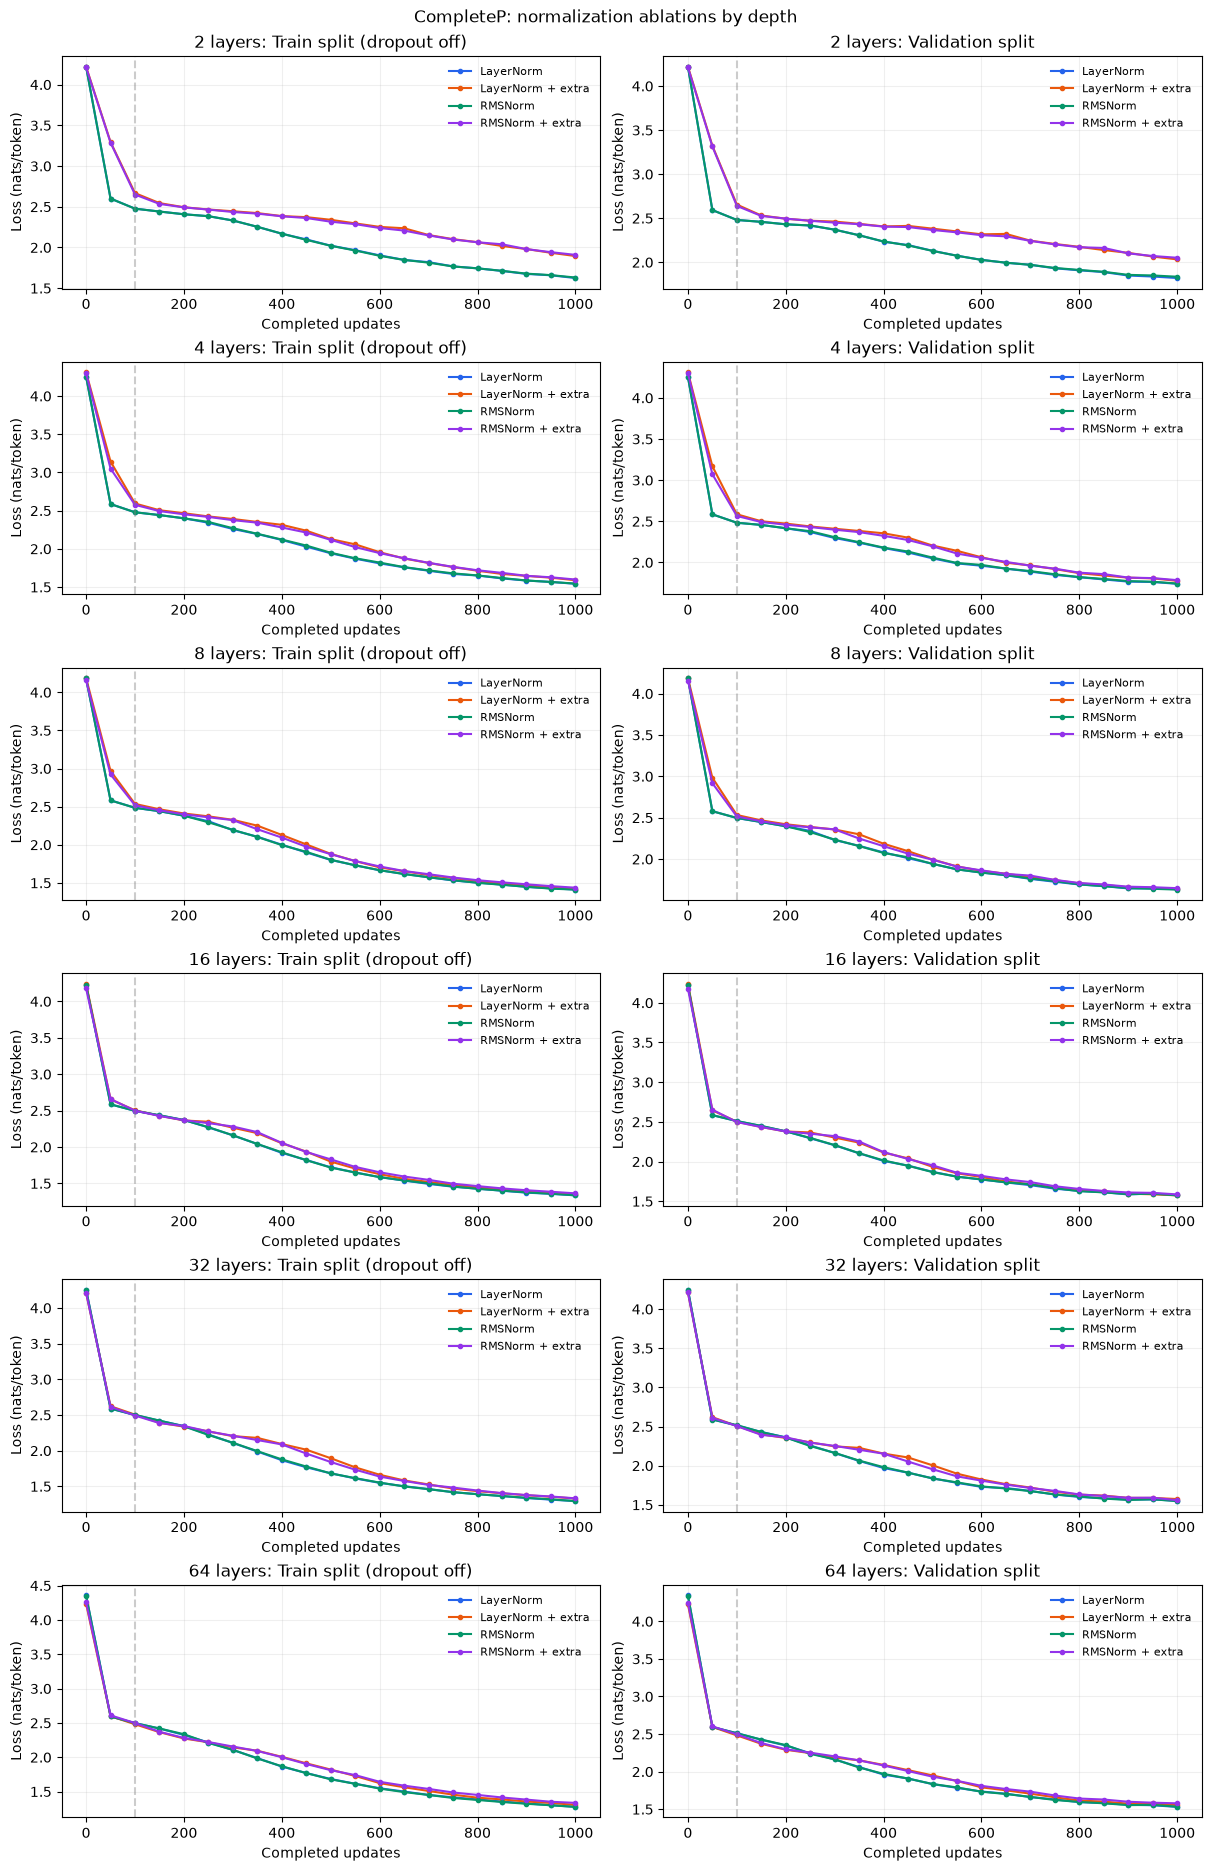

In [1]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Standalone saved-results display: these imports do not initialize a training model.
from pathlib import Path
import json
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Read the existing experiment explicitly; no preceding training cell is needed.
RESULTS_FILE = Path('/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/completep-depth-normalization/20260914T200740Z-176b0e19/metrics.json')
saved = json.loads(RESULTS_FILE.read_text())
COMPARISON_STEP = saved['settings']['max_updates']
labels = {'A': 'LayerNorm', 'B': 'LayerNorm + extra', 'C': 'RMSNorm', 'D': 'RMSNorm + extra'}
colors = {'A': '#2563eb', 'B': '#ea580c', 'C': '#059669', 'D': '#9333ea'}

def evaluation_at(run, step):
    """Use the exact requested step; never substitute an incomplete run's last value."""
    return next((h for h in run['evaluations'] if h['completed_updates'] == step), None)

all_runs = {(r['depth'], r['norm_id']): r for r in saved['results']}
all_depths = sorted({v['depth'] for v in saved['variants']})
# Only complete four-way comparisons enter the tables or figures.
depths = [d for d in all_depths if all(
    (d, norm_id) in all_runs and evaluation_at(all_runs[d, norm_id], COMPARISON_STEP) is not None
    for norm_id in labels
)]
if not depths:
    raise ValueError('No depth has all four variants at the requested comparison step yet.')
runs = {key: value for key, value in all_runs.items() if key[0] in depths}
excluded_depths = [d for d in all_depths if d not in depths]
# Preserve this display separately from the experiment's complete-milestone figures.
plot_dir = (RESULTS_FILE.parent if saved['status'] == 'complete' else
            RESULTS_FILE.parent / 'summaries' / f'{COMPARISON_STEP}-updates-through{max(depths)}')
plot_dir.mkdir(parents=True, exist_ok=True)
print(f'Saved experiment status: {saved["status"]}. Display only; no training is executed.')
print('Comparison step:', COMPARISON_STEP, '| Included depths:', depths)
print('Excluded depths (incomplete four-way comparison):', excluded_depths)

# One row per depth: keep the four curves together and separate train/validation loss.
fig, axes = plt.subplots(len(depths), 2, figsize=(12, 3.1 * len(depths)),
                         squeeze=False, constrained_layout=True)
for row, depth in enumerate(depths):
    for norm_id in labels:
        run = runs.get((depth, norm_id))
        if run is None:
            continue
        h = [e for e in run['evaluations'] if e['completed_updates'] <= COMPARISON_STEP]
        for column, field in enumerate(('train_loss', 'val_loss')):
            axes[row, column].plot([v['completed_updates'] for v in h], [v[field] for v in h],
                                    color=colors[norm_id], label=labels[norm_id], marker='o', markersize=3)
    for column, title in enumerate(('Train split (dropout off)', 'Validation split')):
        ax = axes[row, column]
        ax.set(title=f'{depth} layers: {title}', xlabel='Completed updates', ylabel='Loss (nats/token)')
        ax.axvline(saved['settings']['warmup_iters'], color='gray', linestyle='--', alpha=0.4)
        ax.grid(alpha=0.2)
        if ax.lines:
            ax.legend(frameon=False, fontsize=8)
fig.suptitle('CompleteP: normalization ablations by depth')
fig.savefig(plot_dir / 'loss-curves-by-depth.png', dpi=160)
fig.savefig(plot_dir / 'loss-curves-by-depth.pdf')
plt.show()
### End normalization-ablation code ###


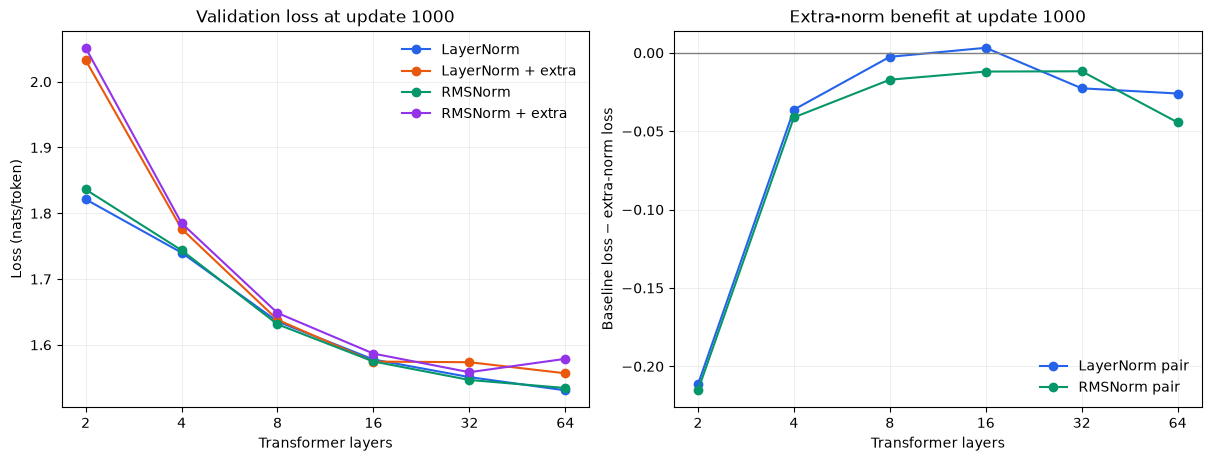

### Validation loss at 1,000 updates

Lower is better. Extra normalization is applied before both W_O and W_2.

| Layers | LayerNorm | LayerNorm + extra | RMSNorm | RMSNorm + extra |
|---:|---:|---:|---:|---:|
| 2 | 1.8213 | 2.0328 | 1.8362 | 2.0515 |
| 4 | 1.7402 | 1.7765 | 1.7438 | 1.7850 |
| 8 | 1.6356 | 1.6382 | 1.6313 | 1.6485 |
| 16 | 1.5778 | 1.5746 | 1.5748 | 1.5868 |
| 32 | 1.5510 | 1.5737 | 1.5467 | 1.5585 |
| 64 | 1.5309 | 1.5568 | 1.5344 | 1.5788 |

### Benefit of extra normalization

Benefit = baseline validation loss − extra-normalization validation loss. Positive means improvement; negative means worse validation loss.

| Layers | LayerNorm pair: benefit | RMSNorm pair: benefit |
|---:|---:|---:|
| 2 | -0.2115 | -0.2153 |
| 4 | -0.0363 | -0.0412 |
| 8 | -0.0026 | -0.0172 |
| 16 | +0.0032 | -0.0119 |
| 32 | -0.0226 | -0.0118 |
| 64 | -0.0260 | -0.0444 |

These are single-seed, matched-update comparisons. Increasing depth also increases parameter count and compute. The tables exclude incomplete depth comparisons.

Source metrics: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/completep-depth-normalization/20260914T200740Z-176b0e19/metrics.json
Saved display figures: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/completep-depth-normalization/20260914T200740Z-176b0e19/summaries/1000-updates-through64


In [2]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Select the same completed step for every point; never substitute a shorter run's last step.
COMPARISON_STEP = saved['settings']['max_updates']
def evaluation_at(run, step):
    return next((h for h in run['evaluations'] if h['completed_updates'] == step), None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for norm_id, label in labels.items():
    points = [(d, evaluation_at(runs[(d, norm_id)], COMPARISON_STEP))
              for d in depths if (d, norm_id) in runs]
    points = [(d, h) for d, h in points if h is not None]
    axes[0].plot([d for d, h in points], [h['val_loss'] for d, h in points],
                 marker='o', label=label, color=colors[norm_id])

# Positive paired difference means the extra norms reduce validation loss.
for base_id, extra_id, label in [('A', 'B', 'LayerNorm pair'), ('C', 'D', 'RMSNorm pair')]:
    points = []
    for depth in depths:
        if (depth, base_id) in runs and (depth, extra_id) in runs:
            base = evaluation_at(runs[(depth, base_id)], COMPARISON_STEP)
            extra = evaluation_at(runs[(depth, extra_id)], COMPARISON_STEP)
            if base is not None and extra is not None:
                points.append((depth, base['val_loss'] - extra['val_loss']))
    axes[1].plot([d for d, v in points], [v for d, v in points], marker='o',
                 label=label, color=colors[base_id])
axes[0].set(title=f'Validation loss at update {COMPARISON_STEP}', ylabel='Loss (nats/token)')
axes[1].set(title=f'Extra-norm benefit at update {COMPARISON_STEP}', ylabel='Baseline loss − extra-norm loss')
axes[1].axhline(0, color='gray', linewidth=1)
for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_xticks(depths, labels=[str(d) for d in depths])
    ax.set_xlabel('Transformer layers')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
fig.savefig(plot_dir / 'validation-and-benefit-by-depth.png', dpi=180)
fig.savefig(plot_dir / 'validation-and-benefit-by-depth.pdf')
plt.show()

# Table 1: validation loss at one matched step, one row per completed depth.
display(Markdown(f'### Validation loss at {COMPARISON_STEP:,} updates\n\nLower is better. Extra normalization is applied before both W_O and W_2.'))
rows = ['| Layers | LayerNorm | LayerNorm + extra | RMSNorm | RMSNorm + extra |',
        '|---:|---:|---:|---:|---:|']
for depth in depths:
    values = [evaluation_at(runs[depth, norm_id], COMPARISON_STEP)['val_loss'] for norm_id in labels]
    rows.append(f'| {depth} | ' + ' | '.join(f'{value:.4f}' for value in values) + ' |')
display(Markdown('\n'.join(rows)))

# Table 2: paired differences preserve both positive and negative outcomes.
display(Markdown('### Benefit of extra normalization\n\nBenefit = baseline validation loss − extra-normalization validation loss. Positive means improvement; negative means worse validation loss.'))
rows = ['| Layers | LayerNorm pair: benefit | RMSNorm pair: benefit |',
        '|---:|---:|---:|']
for depth in depths:
    benefits = [evaluation_at(runs[depth, base], COMPARISON_STEP)['val_loss']
                - evaluation_at(runs[depth, extra], COMPARISON_STEP)['val_loss']
                for base, extra in [('A', 'B'), ('C', 'D')]]
    rows.append(f'| {depth} | {benefits[0]:+.4f} | {benefits[1]:+.4f} |')
display(Markdown('\n'.join(rows)))
display(Markdown('These are single-seed, matched-update comparisons. Increasing depth also increases parameter count and compute. The tables exclude incomplete depth comparisons.'))
print('Source metrics:', RESULTS_FILE)
print('Saved display figures:', plot_dir)
### End normalization-ablation code ###


## Optional comparison with Notebook 07 at four layers

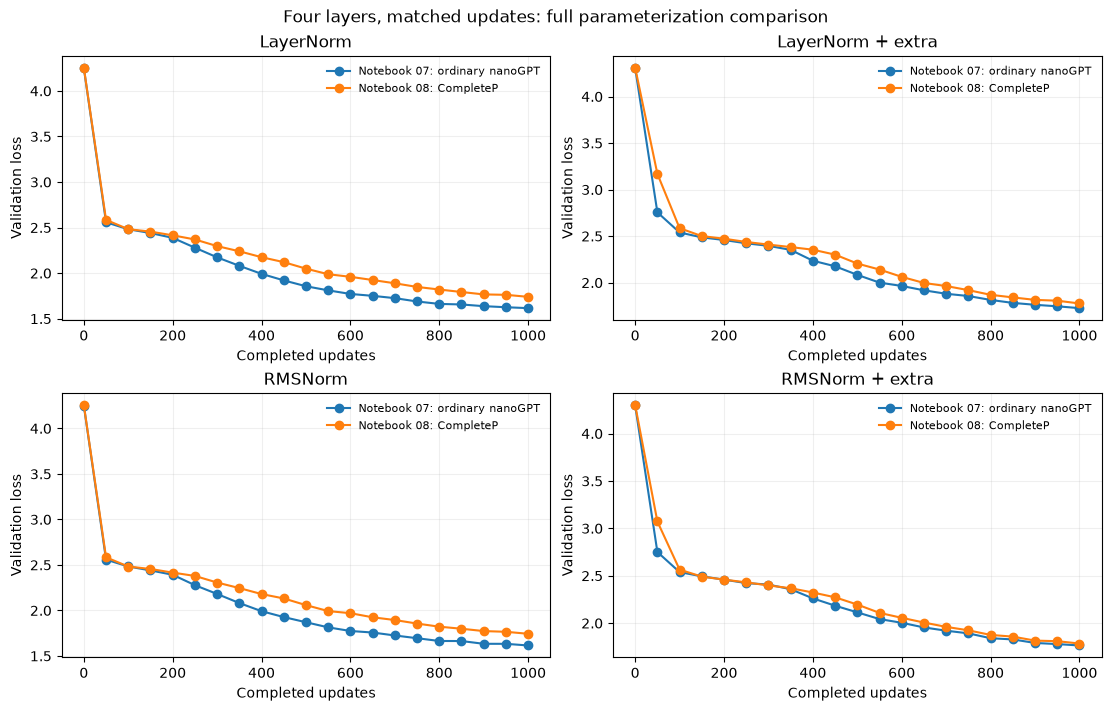

In [3]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Optional: point to Notebook 07's 4-layer metrics. None skips this comparison.
BASELINE_RESULTS_FILE = Path('/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/shakespeare-normalization/20260914T195408Z-4a3ab271/metrics.json')
# BASELINE_RESULTS_FILE = Path('/absolute/path/to/07-run/metrics.json')
if BASELINE_RESULTS_FILE is None:
    print('Optional 4-layer baseline comparison skipped: no baseline file selected.')
else:
    baseline = json.loads(Path(BASELINE_RESULTS_FILE).read_text())
    assert baseline['settings']['n_layer'] == 4, 'Notebook 07 must use four layers.'

    # Require the shared protocol to match before overlaying losses. CompleteP changes
    # initialization/forward/group rules intentionally; these are not asserted equal.
    shared_keys = ('n_embd', 'n_head', 'mlp_ratio', 'block_size', 'vocab_size', 'dropout', 'bias',
                   'norm_eps', 'init_std', 'batch_size', 'gradient_accumulation_steps',
                   'beta1', 'beta2', 'adam_eps', 'weight_decay', 'grad_clip',
                   'learning_rate', 'warmup_iters', 'lr_decay_iters', 'min_lr',
                   'eval_interval', 'eval_batches', 'seed', 'training_window_seed',
                   'evaluation_window_seed', 'device', 'dtype')
    for key in shared_keys:
        assert baseline['settings'][key] == saved['settings'][key], f'Mismatched setting: {key}'
    for key in ('data_hashes', 'window_hashes', 'source_hashes', 'torch_version', 'numpy_version'):
        assert baseline['resume_signature'][key] == saved['resume_signature'][key], f'Mismatch: {key}'

    baseline_runs = {r['id']: r for r in baseline['results']}
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    for ax, norm_id in zip(axes.flat, labels):
        ax.set(title=labels[norm_id], xlabel='Completed updates', ylabel='Validation loss')
        if norm_id not in baseline_runs or (4, norm_id) not in runs:
            ax.text(0.5, 0.5, 'Missing run', transform=ax.transAxes, ha='center')
            continue
        plain = {h['completed_updates']: h['val_loss'] for h in baseline_runs[norm_id]['evaluations']}
        completep = {h['completed_updates']: h['val_loss'] for h in runs[(4, norm_id)]['evaluations']}
        steps = sorted(s for s in set(plain) & set(completep) if s <= saved['settings']['max_updates'])
        ax.plot(steps, [plain[s] for s in steps], marker='o', label='Notebook 07: ordinary nanoGPT')
        ax.plot(steps, [completep[s] for s in steps], marker='o', label='Notebook 08: CompleteP')
        ax.grid(alpha=0.2)
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle('Four layers, matched updates: full parameterization comparison')
    fig.savefig(plot_dir / 'four-layer-baseline-comparison.png', dpi=180)
    fig.savefig(plot_dir / 'four-layer-baseline-comparison.pdf')
    plt.show()
### End normalization-ablation code ###


## Interpretation checklist

- Compare A/B and C/D at the same depth and completed update count.
- Read the sign of the paired difference; do not hide a negative extra-normalization effect.
- Report the actual milestone and one-seed scope; reaching a step target does not itself establish convergence.
- Do not treat equal tokens at different depths as equal compute.
- Use the optional matched-step 4-layer overlay to compare the two parameterizations. It does not isolate the residual multiplier alone.
- More ordinary-nanoGPT depths would be needed to study how CompleteP's relative advantage changes with depth.
- Resume only compatible checkpoints and keep the schedule fixed if extending the runs.